In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
WINDOW_SIZE = 40   # 2s a 20Hz
OVERLAP = 20       # 50%
TEST_SIZE = 0.2
EPOCHS = 15
BATCH_SIZE = 16


In [4]:
archivo_caidas = Path("C:\\Users\\PC\\Documents\\GitHub\\Proyecto-microprocesadores1\\Documentos\\Datos\\datos_capturados_caidas.csv")
archivo_normales = Path("C:\\Users\\PC\\Documents\\GitHub\\Proyecto-microprocesadores1\\Documentos\\Datos\\datos_capturados_normales.csv")

ARCHIVOS = {
    archivo_caidas: 1,      # caída
    archivo_normales: 0     # normal
}

COLUMNAS = ['ax', 'ay', 'az', 'gx', 'gy', 'gz']

datos_totales = []
etiquetas_totales = []

COLUMNAS = [
    'cadera_ax','cadera_ay','cadera_az','cadera_gx','cadera_gy','cadera_gz',
]

cols_giro = [
    'cadera_gx','cadera_gy','cadera_gz',
]

for archivo, etiqueta in ARCHIVOS.items():
    print(f"\n📄 Procesando: {archivo.name}")
    df = pd.read_csv(archivo)

    # Escalar giroscopio para dar mas prioridad al giroscopio
    df[cols_giro] *= 4.0

    for i in range(0, len(df) - WINDOW_SIZE + 1, OVERLAP):
        ventana = df.iloc[i:i+WINDOW_SIZE][COLUMNAS].values
        datos_totales.append(ventana)
        etiquetas_totales.append(etiqueta)


X = np.array(datos_totales, dtype=np.float32)
y = np.array(etiquetas_totales, dtype=np.int32)

unique, counts = np.unique(y, return_counts=True)
for clase, count in zip(unique, counts):
    nombre = "Normal" if clase == 0 else "Caída"



📄 Procesando: datos_capturados_caidas.csv

📄 Procesando: datos_capturados_normales.csv


In [5]:

#Train test y split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=42, stratify=y
)

In [7]:
#Modelo CNN 
model = Sequential([
    Conv1D(32, 3, activation='relu', padding='same', input_shape=(WINDOW_SIZE, 6)),
    MaxPooling1D(2),
    
    Conv1D(64, 3, activation='relu', padding='same'),
    MaxPooling1D(2),
    Dropout(0.4),
    
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    
    Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 40, 32)         │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 20, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 20, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 640)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,905 (187.13 KB)

 Trainable params: 47,905 (187.13 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
#Entrenar modelo
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)
loss, acc = model.evaluate(X_test, y_test)
print(f"\n Pérdida: {loss:.4f} | Precisión: {acc:.4f}")
# Predicciones
y_pred = (model.predict(X_test) > 0.5).astype(int)

Epoch 1/15
454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6947 - loss: 1.8188 - val_accuracy: 0.8771 - val_loss: 0.4229
Epoch 2/15
454/454 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8660 - loss: 0.4405 - val_accuracy: 0.9229 - val_loss: 0.3326
Epoch 3/15
454/454 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8942 - loss: 0.3635 - val_accuracy: 0.9372 - val_loss: 0.2763
Epoch 4/15
454/454 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9124 - loss: 0.2962 - val_accuracy: 0.9300 - val_loss: 0.2140
Epoch 5/15
454/454 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9193 - loss: 0.2223 - val_accuracy: 0.9460 - val_loss: 0.1482
Epoch 6/15
454/454 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9307 - loss: 0.1884 - val_accuracy: 0.9383 - val_loss: 0.1677
Epoch 7/15
454/454 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9399 - loss: 0.1694 - val_accuracy: 0.9548 - val_loss: 0.1225
Epoch 8/15
454/454 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9454 - loss: 0.1494 - val_accuracy: 0.

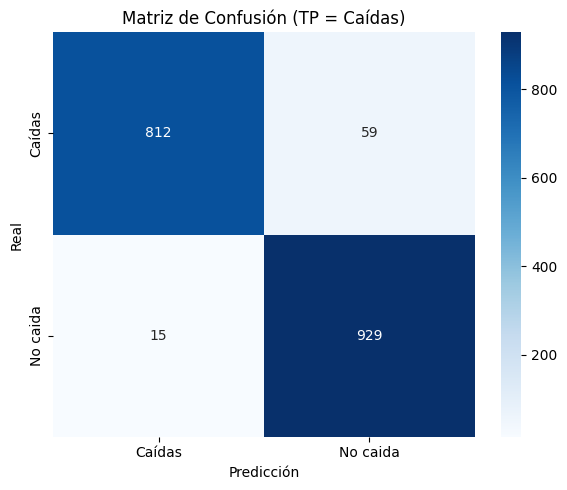

In [10]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Calcular matriz
cm = confusion_matrix(y_test, y_pred, labels=[1, 0])  # Primero la clase "Caída"

# Etiquetas
etiquetas = ['Caídas', 'No caida']

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=etiquetas,
            yticklabels=etiquetas)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión (TP = Caídas)")
plt.tight_layout()
plt.savefig('matriz_confusion_caidas.png', dpi=150)
plt.show()

In [11]:
# Reporte
print("\n Reporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Caída']))


 Reporte de clasificación:
              precision    recall  f1-score   support

      Normal       0.94      0.98      0.96       944
       Caída       0.98      0.93      0.96       871

    accuracy                           0.96      1815
   macro avg       0.96      0.96      0.96      1815
weighted avg       0.96      0.96      0.96      1815



In [12]:
#Guardar modelo
MODEL_PATH = "modelo_cnn_imu.h5"
model.save(MODEL_PATH)
print(f"\n💾 Modelo guardado: {MODEL_PATH}")


💾 Modelo guardado: modelo_cnn_imu.h5


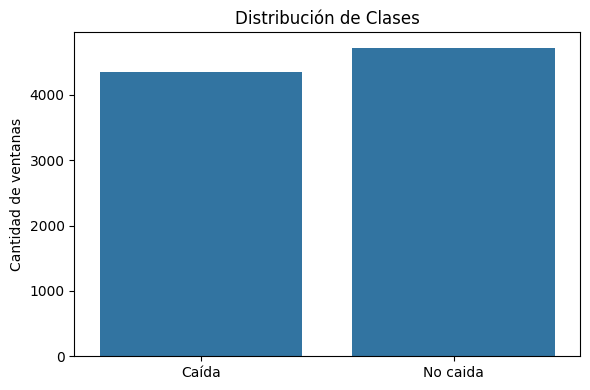

💾 Imagen guardada: class_distribution_caida_primero.png


In [13]:
# Distribución de clases con "Caída" primero
unique, counts = np.unique(y, return_counts=True)

# Reordenar: primero caídas (clase 1), luego normales (clase 0)
counts_reordenados = [counts[unique.tolist().index(1)], counts[unique.tolist().index(0)]]

plt.figure(figsize=(6,4))
sns.barplot(x=['Caída', 'No caida'], y=counts_reordenados)
plt.title("Distribución de Clases")
plt.ylabel("Cantidad de ventanas")
plt.tight_layout()
plt.savefig("class_distribution_caida_primero.png", dpi=150)
plt.show()
print("💾 Imagen guardada: class_distribution_caida_primero.png")


💾 Imagen guardada: confusion_matrix.png


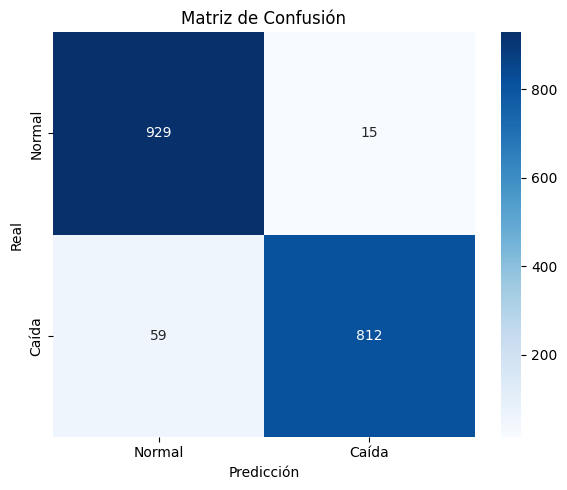

In [14]:

#matriz de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Caída'],
            yticklabels=['Normal', 'Caída'])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
print("💾 Imagen guardada: confusion_matrix.png")

💾 Imagen guardada: training_metrics.png


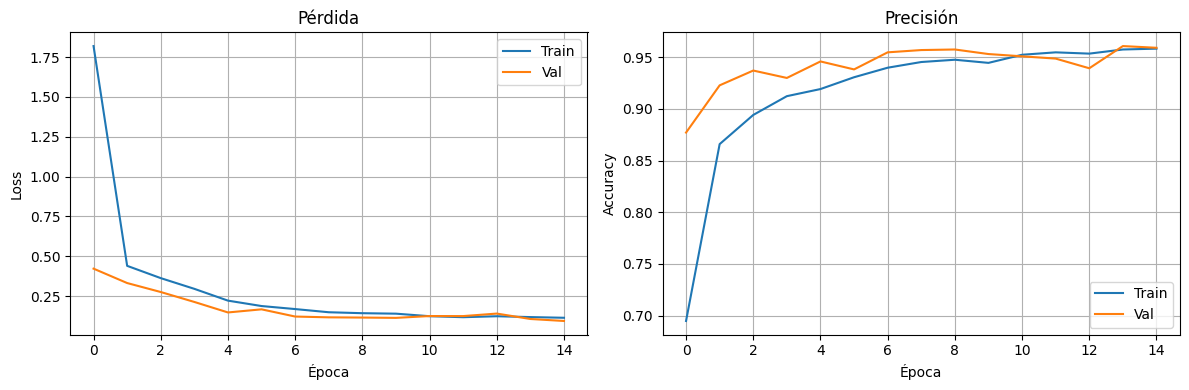

In [15]:
#Grafico entrenamiento
plt.figure(figsize=(12,4))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Pérdida')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Precisión')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("training_metrics.png", dpi=150)
print("💾 Imagen guardada: training_metrics.png")

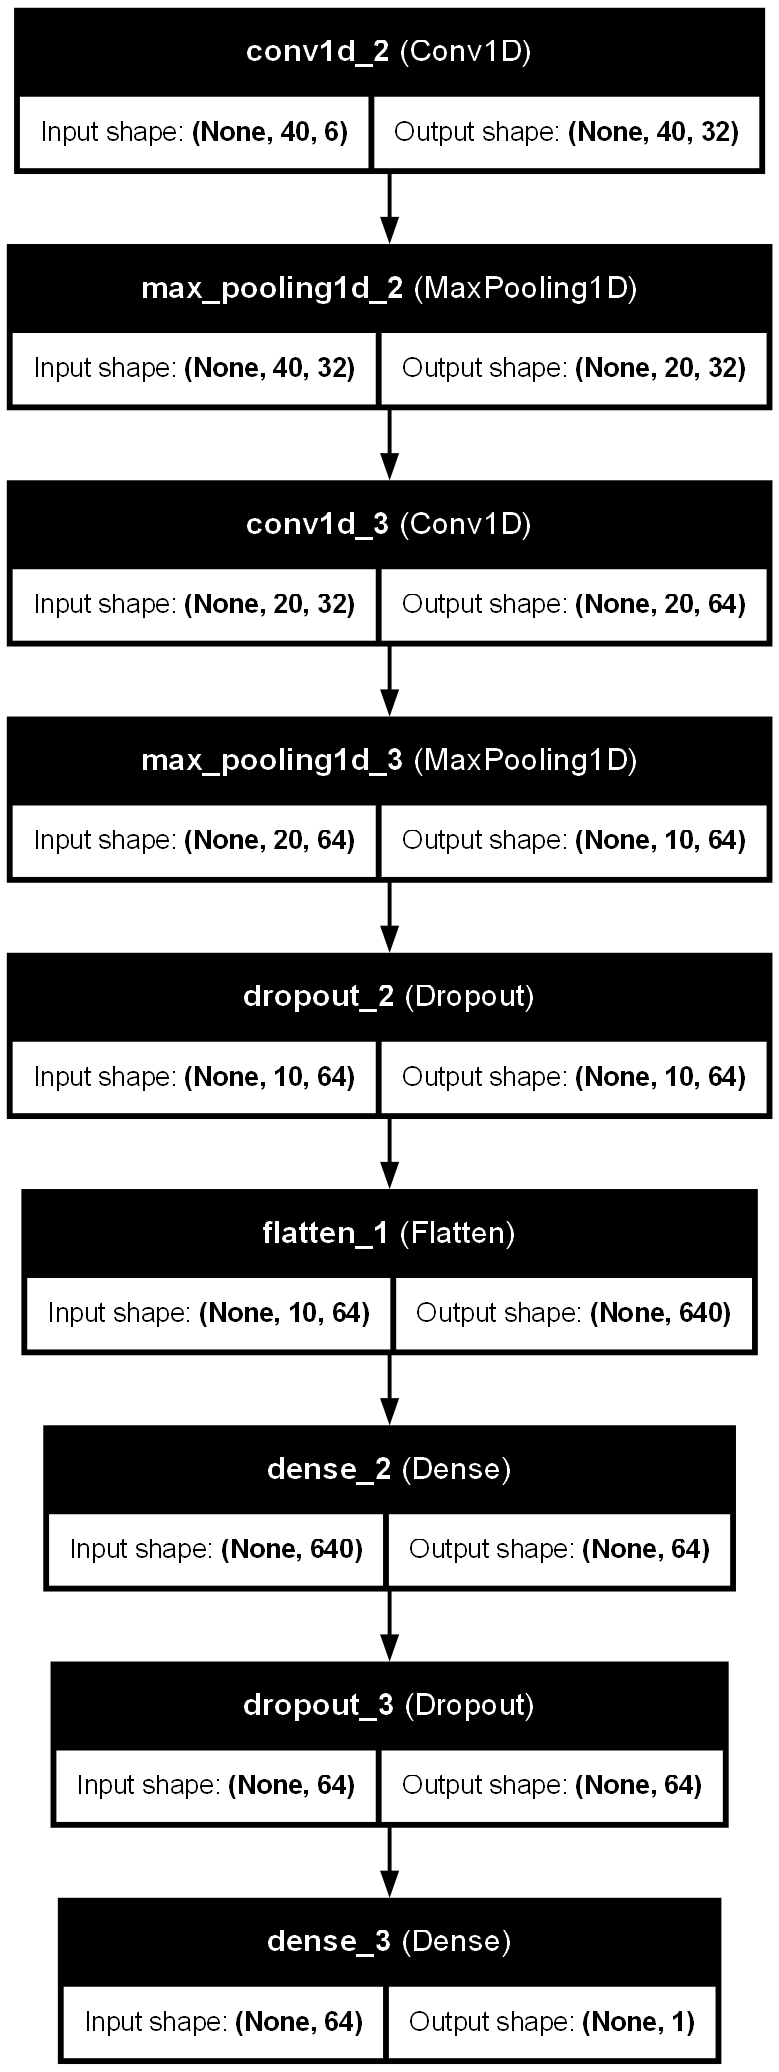

In [16]:
#Grafico de modelo
from tensorflow.keras.utils import plot_model

plot_model(
    model,
    to_file="arquitectura_cnn.png",
    show_shapes=True,
    show_layer_names=True,
    dpi=140
)

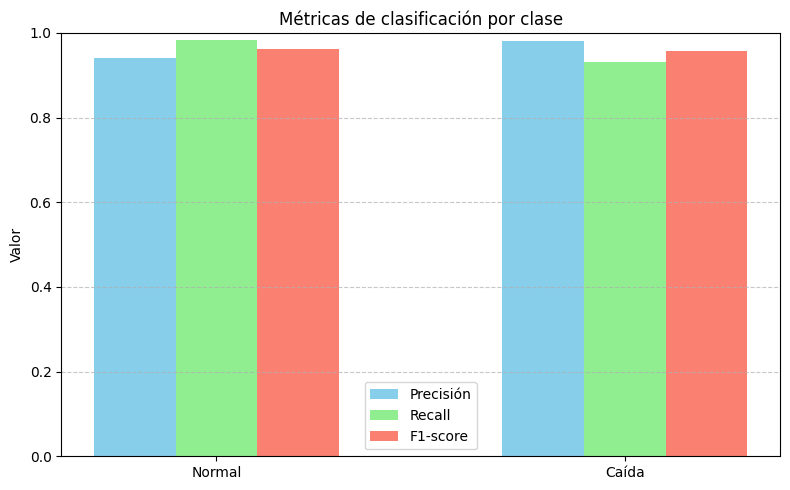

💾 Imagen guardada: metricas_clasificacion.png


In [17]:
from sklearn.metrics import precision_recall_fscore_support

# Obtener métricas
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average=None)

clases = ['Normal', 'Caída']

# Crear gráfico
x = np.arange(len(clases))  # posiciones en x
width = 0.2  # ancho de las barras

plt.figure(figsize=(8,5))
plt.bar(x - width, precision, width, label='Precisión', color='skyblue')
plt.bar(x, recall, width, label='Recall', color='lightgreen')
plt.bar(x + width, f1, width, label='F1-score', color='salmon')

plt.xticks(x, clases)
plt.ylim(0, 1)
plt.ylabel("Valor")
plt.title("Métricas de clasificación por clase")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Guardar imagen
plt.savefig("metricas_clasificacion.png", dpi=150)
plt.show()
print("💾 Imagen guardada: metricas_clasificacion.png")

In [19]:
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Solo operaciones nativas de TFLite
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS
]

tflite_model = converter.convert()

with open("modelo_caidas.tflite", "wb") as f:
    f.write(tflite_model)

print("Modelo guardado correctamente")

INFO:tensorflow:Assets written to: C:\Users\PC\AppData\Local\Temp\tmpntfhdex5\assets


INFO:tensorflow:Assets written to: C:\Users\PC\AppData\Local\Temp\tmpntfhdex5\assets


Saved artifact at 'C:\Users\PC\AppData\Local\Temp\tmpntfhdex5'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 40, 6), dtype=tf.float32, name='keras_tensor_10')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2872113771344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2872113771920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2872113772880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2872113772112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2872113773264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2872113773072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2872113773648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2872113773456: TensorSpec(shape=(), dtype=tf.resource, name=None)
Modelo guardado correctamente
